In [37]:
import pandas as pd
import numpy as np

EPS = 1e-3  # sMAPE 안정화

def load_any(path):
    # utf-8 / cp949 호환 로더
    for enc in ["utf-8", "cp949"]:
        try: return pd.read_csv(path, encoding=enc)
        except: pass
    return pd.read_csv(path)

def to_long(df):
    cols = df.columns
    if ("영업일자" in cols) and ("영업장명_메뉴명" in cols) and ("매출수량" in cols):
        return df[["영업일자","영업장명_메뉴명","매출수량"]].copy()
    # wide → long
    date_col = next((c for c in cols if c=="영업일자" or "일자" in c or "date" in c.lower()), None)
    if date_col is None:
        df = df.copy(); df.insert(0, "영업일자", np.arange(len(df))); date_col = "영업일자"
    long = df.melt(id_vars=[date_col], var_name="영업장명_메뉴명", value_name="매출수량")
    long = long.rename(columns={date_col:"영업일자"})
    return long

def smape_pair(a, b, eps=EPS):
    num = (a - b).abs()
    den = (a.abs() + b.abs()).clip(lower=eps)
    return (2.0 * num / den)

# --- 경로만 바꿔서 실행 ---
path_attn = "../Prediction/v8_01_nonuse_valid.csv"  # 새 모델(Attention)
path_base = "../ens_sub_auto.csv"   # 기존 v7 or v8


p1 = to_long(load_any(path_attn)); p1 = p1.rename(columns={"매출수량":"pred_attn"})
p2 = to_long(load_any(path_base)); p2 = p2.rename(columns={"매출수량":"pred_base"})

m = pd.merge(p1, p2, on=["영업일자","영업장명_메뉴명"], how="inner")
m["smape_pair"] = smape_pair(m["pred_attn"], m["pred_base"])

print("Pairwise sMAPE (mean) =", m["smape_pair"].mean().round(4))
print("Pairwise sMAPE (p90)  =", m["smape_pair"].quantile(0.90).round(4))

# 어디서 차이가 큰지 TOP 리스트
top_rows = m.nlargest(40, "smape_pair")[["영업일자","영업장명_메뉴명","pred_attn","pred_base","smape_pair"]]
top_items = (m.groupby("영업장명_메뉴명")["smape_pair"].mean()
               .sort_values(ascending=False).head(40).reset_index())
display(top_rows); display(top_items)


Pairwise sMAPE (mean) = 0.2931
Pairwise sMAPE (p90)  = 0.8423


,영업일자,영업장명_메뉴명,pred_attn,pred_base,smape_pair
11076,TEST_02+3일,카페테리아_오픈푸드,1.000000,268.523005,1.985159
11075,TEST_02+2일,카페테리아_오픈푸드,1.000000,256.150153,1.984445
11077,TEST_02+4일,카페테리아_오픈푸드,1.000000,226.429317,1.982412
10340,TEST_07+2일,카페테리아_단체식 18000(신),1.000000,188.307738,1.978870
11118,TEST_08+3일,카페테리아_오픈푸드,1.000000,155.990337,1.974521
11119,TEST_08+4일,카페테리아_오픈푸드,1.000000,111.137670,1.964330
1448,TEST_06+7일,느티나무 셀프BBQ_콜라 (단체),1.000000,109.769024,1.963889
13123,TEST_04+6일,화담숲주막_해물파전,1.000000,105.946702,1.962598
8488,TEST_02+5일,연회장_Cass Beer,1.000000,105.401589,1.962407
9252,TEST_01+6일,연회장_Regular Coffee,1.000000,104.568367,1.962110


,영업장명_메뉴명,smape_pair
0,연회장_Regular Coffee,1.687709
1,연회장_Cass Beer,1.687396
2,담하_(단체) 은이버섯 갈비탕,1.598187
3,담하_(단체) 한우 우거지 국밥,1.394112
4,카페테리아_오픈푸드,1.136708
5,느티나무 셀프BBQ_카스 병(단체),0.969991
6,담하_(단체) 생목살 김치전골 2.0,0.913477
7,담하_들깨 양지탕,0.861660
8,미라시아_브런치(대인) 주말,0.858924
9,"미라시아_(단체)브런치주중 36,000",0.766932


{'파일 A': 'ens_sub_auto.csv', '파일 B': 'v8_01_nonuse_valid.csv', '공통 날짜 수': 70, '공통 메뉴 수': 193, 'vA 평균': 9.418880419806314, 'vB 평균': 8.2198329065037, '평균 차이(B-A)': -1.1990475133026115}


,영업일자,메뉴,예측_vA,예측_vB,차이,절대차이
11801,TEST_05+7일,포레스트릿_꼬치어묵,841.402514,393.625648,-447.776866,447.776866
12011,TEST_05+7일,포레스트릿_생수,591.559654,197.564370,-393.995284,393.995284
13117,TEST_03+7일,화담숲주막_해물파전,700.415448,429.094744,-271.320704,271.320704
11076,TEST_02+3일,카페테리아_오픈푸드,268.523005,1.000000,-267.523005,267.523005
11800,TEST_05+6일,포레스트릿_꼬치어묵,649.816873,384.471192,-265.345681,265.345681
11075,TEST_02+2일,카페테리아_오픈푸드,256.150153,1.000000,-255.150153,255.150153
13114,TEST_03+4일,화담숲주막_해물파전,648.449732,412.428014,-236.021718,236.021718
11077,TEST_02+4일,카페테리아_오픈푸드,226.429317,1.000000,-225.429317,225.429317
13115,TEST_03+5일,화담숲주막_해물파전,623.717240,399.501850,-224.215390,224.215390
11871,TEST_05+7일,포레스트릿_떡볶이,521.929027,299.695075,-222.233952,222.233952


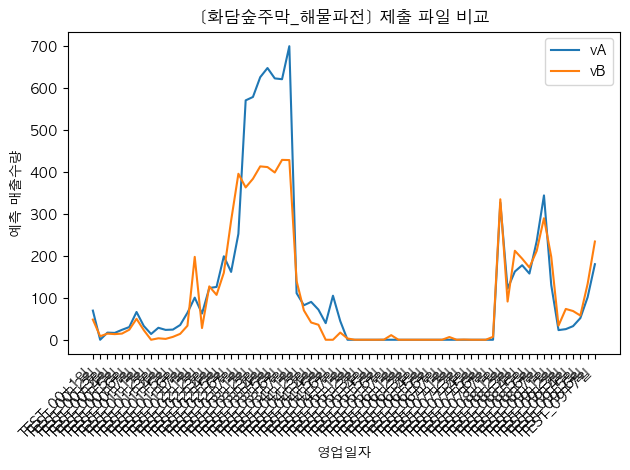

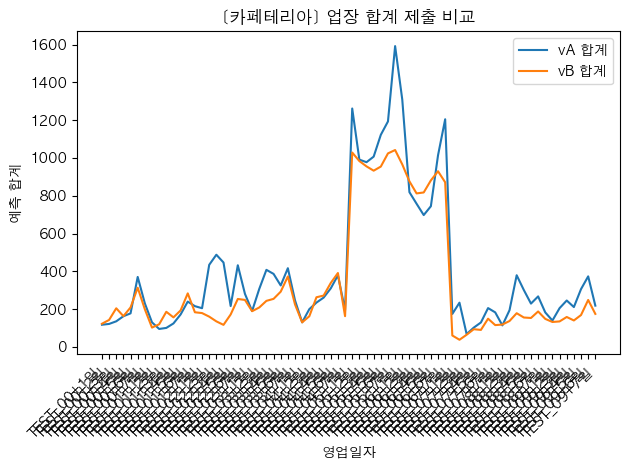

/var/folders/r4/sdnz117n6pl22zr9jhhv5vbm0000gn/T/ipykernel_40653/1275858538.py:142: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/widohun/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


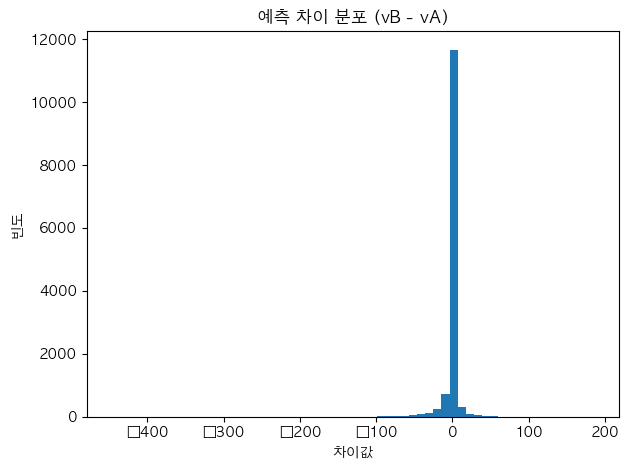

In [36]:
# =========================
# 제출 CSV 비교/시각화 유틸 (pandas + matplotlib)
# 제출 포맷: 첫 컬럼 '영업일자', 나머지는 '영업장명_메뉴명'
# =========================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# (선택) macOS 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'

def load_submission(path: str) -> pd.DataFrame:
    """제출 CSV 로드. 첫 컬럼명이 '영업일자'가 아니면 유사 키워드로 추정 후 정규화."""
    df = pd.read_csv(path)
    if '영업일자' not in df.columns:
        cands = [c for c in df.columns if ('영업' in c) or ('date' in c.lower())]
        if not cands:
            raise ValueError(f"'영업일자' 컬럼을 찾을 수 없음: {path}")
        df = df.rename(columns={cands[0]: '영업일자'})
    df['영업일자'] = df['영업일자'].astype(str)
    # 숫자 컬럼을 확실하게 numeric으로
    for c in df.columns:
        if c == '영업일자': 
            continue
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def align_submissions(df_a: pd.DataFrame, df_b: pd.DataFrame):
    """
    공통 '영업일자' & 공통 메뉴 컬럼만 남기고,
    '영업일자'는 A의 순서를 기준으로 정렬 정합.
    """
    common_cols = ['영업일자'] + [c for c in df_a.columns if c != '영업일자' and c in df_b.columns]
    df_a2 = df_a[common_cols].copy()
    df_b2 = df_b[common_cols].copy()

    order = list(df_a2['영업일자'])
    inter = sorted(set(order) & set(df_b2['영업일자']), key=order.index)
    key = pd.DataFrame({'영업일자': inter})

    df_a2 = key.merge(df_a2, on='영업일자', how='left')
    df_b2 = key.merge(df_b2, on='영업일자', how='left')
    return df_a2, df_b2

def melt_submissions(df: pd.DataFrame) -> pd.DataFrame:
    """Wide → Long 변환: (영업일자, 메뉴, 예측)"""
    return df.melt(id_vars='영업일자', var_name='메뉴', value_name='예측')

def build_long_join(df_a_long: pd.DataFrame, df_b_long: pd.DataFrame, label_a='A', label_b='B') -> pd.DataFrame:
    """두 제출을 Long 포맷으로 조인하고 차이/절대차이를 계산."""
    merged = df_a_long.merge(df_b_long, on=['영업일자','메뉴'], suffixes=(f'_{label_a}', f'_{label_b}'))
    merged['차이'] = merged[f'예측_{label_b}'] - merged[f'예측_{label_a}']
    merged['절대차이'] = merged['차이'].abs()
    return merged

def compare_submissions(path_a: str, path_b: str, label_a='A', label_b='B', topk=20, save_top_csv: str|None=None):
    """
    두 제출 CSV를 비교할 Long 데이터프레임을 생성하고,
    절대차이 Top-K 표와 요약치를 반환.
    """
    df_a = load_submission(path_a)
    df_b = load_submission(path_b)
    df_a2, df_b2 = align_submissions(df_a, df_b)
    long_a = melt_submissions(df_a2).rename(columns={'예측': f'예측_{label_a}'})
    long_b = melt_submissions(df_b2).rename(columns={'예측': f'예측_{label_b}'})
    merged = build_long_join(long_a, long_b, label_a=label_a, label_b=label_b)

    # 요약
    summary = {
        "파일 A": os.path.basename(path_a),
        "파일 B": os.path.basename(path_b),
        "공통 날짜 수": int(merged['영업일자'].nunique()),
        "공통 메뉴 수": int(merged['메뉴'].nunique()),
        f"{label_a} 평균": float(merged[f'예측_{label_a}'].mean()),
        f"{label_b} 평균": float(merged[f'예측_{label_b}'].mean()),
        "평균 차이(B-A)": float(merged['차이'].mean()),
    }

    # 절대차이 Top-K
    top = merged.nlargest(topk, '절대차이').copy()
    if save_top_csv:
        top.to_csv(save_top_csv, index=False, encoding='utf-8-sig')
    return merged, summary, top

def plot_menu_series(merged_long: pd.DataFrame, menu_name: str, label_a='A', label_b='B', save_path: str|None=None):
    """특정 메뉴(업장_메뉴명)의 예측 시계열을 두 파일 라인으로 비교."""
    sub = merged_long[merged_long['메뉴'] == menu_name].copy()
    if sub.empty:
        raise ValueError(f"메뉴가 없습니다: {menu_name}")
    order = sub['영업일자'].drop_duplicates().tolist()
    sub['영업일자'] = pd.Categorical(sub['영업일자'], categories=order, ordered=True)
    sub = sub.sort_values('영업일자')

    plt.figure()
    plt.plot(sub['영업일자'], sub[f'예측_{label_a}'], label=f'{label_a}')
    plt.plot(sub['영업일자'], sub[f'예측_{label_b}'], label=f'{label_b}')
    plt.title(f"[{menu_name}] 제출 파일 비교")
    plt.xlabel("영업일자")
    plt.ylabel("예측 매출수량")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_store_aggregate(merged_long: pd.DataFrame, store_name: str, label_a='A', label_b='B', save_path: str|None=None):
    """업장 단위(메뉴 합산) 시계열 비교."""
    sub = merged_long.copy()
    sub['업장'] = sub['메뉴'].str.split('_', n=1, expand=True)[0]
    sub = sub[sub['업장'] == store_name]
    if sub.empty:
        raise ValueError(f"업장이 없습니다: {store_name}")

    grp = sub.groupby('영업일자')[[f'예측_{label_a}', f'예측_{label_b}']].sum().reset_index()
    order = grp['영업일자'].tolist()
    grp['영업일자'] = pd.Categorical(grp['영업일자'], categories=order, ordered=True)
    grp = grp.sort_values('영업일자')

    plt.figure()
    plt.plot(grp['영업일자'], grp[f'예측_{label_a}'], label=f'{label_a} 합계')
    plt.plot(grp['영업일자'], grp[f'예측_{label_b}'], label=f'{label_b} 합계')
    plt.title(f"[{store_name}] 업장 합계 제출 비교")
    plt.xlabel("영업일자")
    plt.ylabel("예측 합계")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def plot_diff_hist(merged_long: pd.DataFrame, bins: int = 50, label_a='A', label_b='B', save_path: str|None=None):
    """B-A 차이 분포 히스토그램(전체 메뉴/날짜)."""
    plt.figure()
    plt.hist(merged_long['차이'].dropna(), bins=bins)
    plt.title(f"예측 차이 분포 ({label_b} - {label_a})")
    plt.xlabel("차이값")
    plt.ylabel("빈도")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# ========== 사용 예시 ==========
# merged, info, topk = compare_submissions(
#     "/mnt/data/제출A.csv",
#     "/mnt/data/제출B.csv",
#     label_a="vA", label_b="vB",
#     topk=30,
#     save_top_csv="/mnt/data/제출_절대차이_TOP30.csv"
# )
# print(info)         # 요약 정보
# topk.head()         # 큰 차이 Top-표

# # 특정 메뉴 비교
# plot_menu_series(merged, "담하_메뉴이름", "vA", "vB")

# # 업장 합계 비교
# plot_store_aggregate(merged, "담하", "vA", "vB")

# # 전체 차이 분포
# plot_diff_hist(merged, bins=60, label_a="vA", label_b="vB")

# ========== 사용 예시 ==========
path_a = "../ens_sub_auto.csv"  # 새 모델(Attention)
path_b = "../Prediction/v8_01_nonuse_valid.csv"   # 기존 v7 or v8
#path_b = "../ens_sub_4_clipped.csv"   # 기존 v7 or v8
merged, info, topk = compare_submissions(
    path_a,
    path_b,
    label_a="vA", label_b="vB",
    topk=30,
    save_top_csv="../data/제출_절대차이_TOP30.csv"
)
print(info)         # 요약 정보
display(topk)         # 큰 차이 Top-표
	
# # 특정 메뉴 비교
plot_menu_series(merged, "화담숲주막_해물파전", "vA", "vB")

# # 업장 합계 비교
plot_store_aggregate(merged, "카페테리아", "vA", "vB")
# # 전체 차이 분포
plot_diff_hist(merged, bins=60, label_a="vA", label_b="vB")
